In [26]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */
.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */
.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */
.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */
.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */
.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */
.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))

# red wine 품질 등급 예측
1. 데이터 셋 확보 & 전처리
    결측치 처리 -> 독립(입력)변수와 종속(타겟)변수를 분리 -> 독립변수의 스케일조정(StandardScaler) 
    -> 종속변수의 균형을 확인
    -> 종속변수 원핫인코딩(pd.get_dummies) -> 훈련셋과 테스트셋분리(train_test_split)
2. 모델구성
3. 모델학습과정 설정(다중분류)
4. 모델학습(callbacks, compute_class_weight를 이용)
5. 모델 평가(시각화, 평가, 교차표 - 테스트셋)
6. 모델 저장/예측

# 1. 데이터셋 확보 및 전처리

In [9]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Dropout, BatchNormalization
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras import metrics # metrics.Recall, metrics.Precision
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback, ReduceLROnPlateau
from matplotlib import pyplot as plt

In [10]:
redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine.info() # 결측치 없음
# redwine = np.loadtxt('data/winequality-red.csv', delimiter=';', skiprows=1) 넘파이배열로

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [11]:
# 독립(입력)변수와 종속(타겟)변수를 분리
X_redwine = redwine.iloc[:, :-1].to_numpy() #.values과 유사. numpy로 변경
y_redwine = redwine.iloc[:, -1]#.values
X_redwine.shape, y_redwine.shape

((1599, 11), (1599,))

In [12]:
# 독립변수의 스케일조정
scaler = StandardScaler()
# scaler.fit(X_redwine)
# scaled_X_redwine = scaler.transform(X_redwine)
scaled_X_redwine = scaler.fit_transform(X_redwine)

In [13]:
# 종속변수의 원핫인코딩
Y_redwine = pd.get_dummies(y_redwine).values
np.c_[y_redwine[2:4], Y_redwine[2:4]] # 원데이터와 원핫인코딩

array([[5, 0, 0, 1, 0, 0, 0],
       [6, 0, 0, 0, 1, 0, 0]], dtype=int64)

In [14]:
# 종속변수의 균형을 확인
y_redwine.value_counts(normalize=True)

5    0.425891
6    0.398999
7    0.124453
4    0.033146
8    0.011257
3    0.006254
Name: quality, dtype: float64

In [15]:
# 독립변수와 타겟변수
scaled_X_redwine.shape, Y_redwine.shape

((1599, 11), (1599, 6))

In [16]:
# 훈련셋과 테스트셋 분리(층화추출) = 7 : 3
X_train, X_test, Y_train, Y_test = train_test_split(scaled_X_redwine,
                                                   Y_redwine,
                                                   test_size=0.3,
                                                   #train_size=0.7,
                                                   stratify=Y_redwine, # 층화추출
                                                   random_state=12) # seed값
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((1119, 11), (480, 11), (1119, 6), (480, 6))

# 2. 모델구성
- 입력 11 -> 64 -> 50 -> 30 -> 출력 6
- He초기화 : 층이 깊을 때 활성화함수를 relu사용시

In [17]:
model = Sequential(name='sequential')
model.add(Input(11))
model.add(Dense(units=64, activation='relu', kernel_initializer=HeNormal(seed=42)))
model.add(Dense(units=50, activation='relu', kernel_initializer='he_normal'))
model.add(Dropout(0.1))
model.add(Dense(units=30, activation='relu', kernel_initializer='he_normal'))
model.add(Dense(units=6, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                768       
                                                                 
 dense_1 (Dense)             (None, 50)                3250      
                                                                 
 dropout (Dropout)           (None, 50)                0         
                                                                 
 dense_2 (Dense)             (None, 30)                1530      
                                                                 
 dense_3 (Dense)             (None, 6)                 186       
                                                                 
Total params: 5,734
Trainable params: 5,734
Non-trainable params: 0
_________________________________________________________________


# 3. 학습과정 설정

In [18]:
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy', 
                      metrics.Recall(name='recall'), 
                      metrics.Precision(name='precision')])

# 4. 학습시키기
- callbacks 이용

In [19]:
%%time
earlyStopping = EarlyStopping(monitor='val_loss', patience=50)
hist = model.fit(X_train, Y_train,
                validation_split=0.2, # 학습셋의 20%를 검증셋으로
                # class_weight=class_weight_dict,
                callbacks=[earlyStopping],
                epochs=200, 
                verbose=2)

Epoch 1/200
28/28 - 2s - loss: 1.9233 - accuracy: 0.2492 - recall: 0.0547 - precision: 0.1769 - val_loss: 1.4983 - val_accuracy: 0.4062 - val_recall: 0.0982 - val_precision: 0.3438 - 2s/epoch - 56ms/step
Epoch 2/200
28/28 - 0s - loss: 1.2572 - accuracy: 0.4659 - recall: 0.1587 - precision: 0.4863 - val_loss: 1.2915 - val_accuracy: 0.4777 - val_recall: 0.2232 - val_precision: 0.6757 - 81ms/epoch - 3ms/step
Epoch 3/200
28/28 - 0s - loss: 1.1124 - accuracy: 0.5553 - recall: 0.2749 - precision: 0.6029 - val_loss: 1.1940 - val_accuracy: 0.5268 - val_recall: 0.3125 - val_precision: 0.6863 - 124ms/epoch - 4ms/step
Epoch 4/200
28/28 - 0s - loss: 1.0452 - accuracy: 0.5765 - recall: 0.3698 - precision: 0.6440 - val_loss: 1.1435 - val_accuracy: 0.5312 - val_recall: 0.3661 - val_precision: 0.6212 - 133ms/epoch - 5ms/step
Epoch 5/200
28/28 - 0s - loss: 1.0186 - accuracy: 0.5911 - recall: 0.4089 - precision: 0.6343 - val_loss: 1.1197 - val_accuracy: 0.5357 - val_recall: 0.4018 - val_precision: 0.625

Epoch 41/200
28/28 - 0s - loss: 0.6367 - accuracy: 0.7274 - recall: 0.6860 - precision: 0.7733 - val_loss: 1.0537 - val_accuracy: 0.5982 - val_recall: 0.5625 - val_precision: 0.6429 - 110ms/epoch - 4ms/step
Epoch 42/200
28/28 - 0s - loss: 0.6384 - accuracy: 0.7385 - recall: 0.6927 - precision: 0.7702 - val_loss: 1.0448 - val_accuracy: 0.6339 - val_recall: 0.5804 - val_precision: 0.6633 - 82ms/epoch - 3ms/step
Epoch 43/200
28/28 - 0s - loss: 0.6187 - accuracy: 0.7453 - recall: 0.6883 - precision: 0.7719 - val_loss: 1.0579 - val_accuracy: 0.6295 - val_recall: 0.5670 - val_precision: 0.6480 - 80ms/epoch - 3ms/step
Epoch 44/200
28/28 - 0s - loss: 0.6165 - accuracy: 0.7240 - recall: 0.6860 - precision: 0.7694 - val_loss: 1.0476 - val_accuracy: 0.6071 - val_recall: 0.5580 - val_precision: 0.6345 - 93ms/epoch - 3ms/step
Epoch 45/200
28/28 - 0s - loss: 0.6020 - accuracy: 0.7486 - recall: 0.7017 - precision: 0.7811 - val_loss: 1.0820 - val_accuracy: 0.6116 - val_recall: 0.5804 - val_precision: 

# 5. 모델평가
- 시각화, 평가, 교차표

In [20]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall', 'precision', 'val_loss', 'val_accuracy', 'val_recall', 'val_precision'])

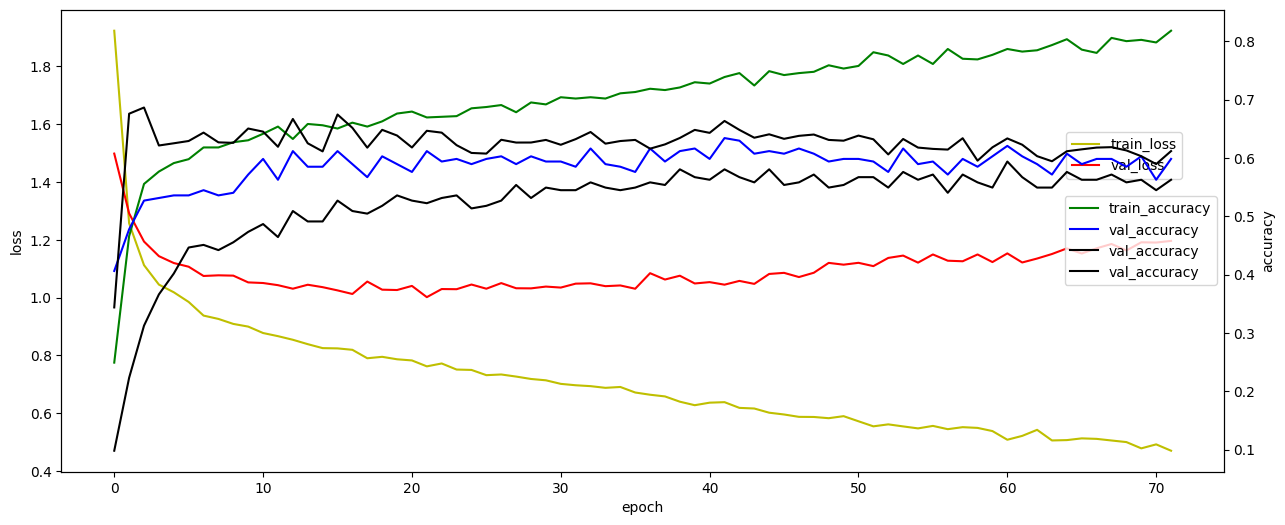

In [21]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.plot(hist.history['val_recall'], 'k', label='val_accuracy')
acc_ax.plot(hist.history['val_precision'], 'k', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [22]:
# 평가
loss, acc, recall, precision = model.evaluate(X_test, Y_test, verbose=0)
print('정확도 :', acc)
print('재현율 :', recall)
print('정밀도 :', precision)

정확도 : 0.6270833611488342
재현율 : 0.5895833373069763
정밀도 : 0.6417233347892761


In [23]:
# 교차표를 위한 y_hat
y_hat = model.predict(X_test).argmax(axis=1) + 3 # 예측값
y = Y_test.argmax(axis=1) + 3 # 실제값
pd.crosstab(y, y_hat, rownames=['실제'], colnames=['예측'])

15/15 [==============================] - 0s 2ms/step


예측,3,4,5,6,7,8
실제,,,,,,
3,0,0,2,1,0,0
4,1,0,9,5,1,0
5,1,2,140,56,5,0
6,0,0,47,124,20,1
7,0,0,4,19,37,0
8,0,0,0,1,4,0


# 6. 모델 사용

In [24]:
X_redwine[0]

array([ 7.4   ,  0.7   ,  0.    ,  1.9   ,  0.076 , 11.    , 34.    ,
        0.9978,  3.51  ,  0.56  ,  9.4   ])

In [25]:
data = [[ 7.4,0.7, 0.,  1.9,  0.076, 11., 34. , 0.9978,  3.51  ,  0.56  ,  9.4   ]]
input_data = scaler.transform(data)
model.predict(input_data).argmax(axis=1)+3

1/1 [==============================] - 0s 103ms/step


array([5], dtype=int64)